<a href="https://colab.research.google.com/github/smin12345/NLP_Practice/blob/main/NLP_week02_2021040029_%EC%9D%B4%EC%83%81%EB%AF%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2주차 실습: 자연어와 텍스트 데이터 이해

**과목:** 자연어처리(NLP)  
**환경:** Google Colab / Python 3  

> **배포용 반완성 노트북**입니다. 안내된 순서대로 실행하고, `TODO`와 **체크포인트**를 직접 완성하세요.

## 오늘의 목표
1. 텍스트 데이터를 표 형태로 불러오고 구조를 점검한다.
2. 문서·문장·토큰 등 텍스트 데이터의 기본 단위를 구분한다.
3. 길이, 빈도, 어휘 다양성 등 기초 탐색적 텍스트 분석을 수행한다.
4. 한글 텍스트와 UTF-8 인코딩·유니코드 정규화 이슈를 확인한다.
5. 분석 전 데이터 품질·개인정보·저작권 관점을 점검한다.

## 실습 원칙
- `TODO`는 직접 작성하고 실행 결과를 남깁니다.
- 숫자와 그래프를 출력하는 것에서 멈추지 않고, **무엇을 의미하는지** 체크포인트에 기록합니다.
- 이 자료의 데이터는 교육용 예시입니다. 실제 데이터를 사용할 때에는 출처·라이선스·개인정보 여부를 먼저 확인합니다.
- 외부 생성형 AI나 자료를 사용했다면 사용 범위와 검증 과정을 README 또는 노트북에 기록합니다.


## 0. 실습 데이터 소개

이번 실습에서는 온라인 영화 리뷰를 축약한 **교육용 예시 데이터**를 사용합니다. 실제 프로젝트에서는 데이터의 출처, 수집일, 이용 조건, 개인정보 포함 여부를 반드시 확인해야 합니다.

In [17]:
import re
from collections import Counter
import pandas as pd

reviews = [
    (1, '정말 재미있어요! 배우들의 연기가 인상적이었습니다.', 1, '2026-08-25'),
    (2, '스토리는 평범하지만 음악이 좋네요.', 1, '2026-08-25'),
    (3, '기대보다 지루했고 결말이 아쉬웠습니다.', 0, '2026-08-26'),
    (4, '영상미는 훌륭합니다. 다만 전개가 조금 느려요.', 1, '2026-08-26'),
    (5, '다시는 보고 싶지 않은 영화예요...', 0, '2026-08-27'),
    (6, '가족과 함께 보기 좋은 따뜻한 작품입니다 :)', 1, '2026-08-27'),
    (7, '배우는 좋았지만 대사가 잘 들리지 않았어요.', 0, '2026-08-28'),
    (8, '추천합니다! 다음 편도 꼭 보고 싶어요.', 1, '2026-08-28'),
    (9, '별로예요. 러닝타임이 너무 길게 느껴집니다.', 0, '2026-08-29'),
    (10, '생각할 거리를 주는 좋은 영화였습니다.', 1, '2026-08-29'),
]

df = pd.DataFrame(reviews, columns=['review_id', 'text', 'label', 'date'])

# TODO 1. label 값(1, 0)을 각각 '긍정', '부정'으로 바꾼 label_name 열을 만드세요.
# 힌트: map()
# df['label_name'] = ______________________________________________
df['label_name'] = df['label'].map({1: '긍정', 0: '부정'})

df


,review_id,text,label,date,label_name
0,1,정말 재미있어요! 배우들의 연기가 인상적이었습니다.,1,2026-08-25,긍정
1,2,스토리는 평범하지만 음악이 좋네요.,1,2026-08-25,긍정
2,3,기대보다 지루했고 결말이 아쉬웠습니다.,0,2026-08-26,부정
3,4,영상미는 훌륭합니다. 다만 전개가 조금 느려요.,1,2026-08-26,긍정
4,5,다시는 보고 싶지 않은 영화예요...,0,2026-08-27,부정
5,6,가족과 함께 보기 좋은 따뜻한 작품입니다 :),1,2026-08-27,긍정
6,7,배우는 좋았지만 대사가 잘 들리지 않았어요.,0,2026-08-28,부정
7,8,추천합니다! 다음 편도 꼭 보고 싶어요.,1,2026-08-28,긍정
8,9,별로예요. 러닝타임이 너무 길게 느껴집니다.,0,2026-08-29,부정
9,10,생각할 거리를 주는 좋은 영화였습니다.,1,2026-08-29,긍정


## 1. 텍스트 데이터의 기본 단위

- **코퍼스(corpus)**: 분석을 위해 모은 텍스트 전체
- **문서(document)**: 코퍼스를 구성하는 개별 텍스트 (여기서는 리뷰 한 건)
- **문장(sentence)**: 문서 안의 의미 단위
- **토큰(token)**: 분석을 위해 나눈 단위. 단어, 형태소, 서브워드 등이 될 수 있음

같은 문장도 토큰화 규칙에 따라 결과가 달라집니다. 지금은 원리를 이해하기 위해 간단한 정규표현식 토크나이저를 사용합니다.

In [ ]:
sample = df.loc[0, 'text'] #'정말 재미있어요! 배우들의 연기가 인상적이었습니다.'
print('원문:', sample)
print('공백 기준:', sample.split())

# TODO 2. 한글·영문·숫자로 이루어진 덩어리만 추출하는 정규표현식 토큰화를 완성하세요.
# 힌트: re.findall()
regex_tokens = re.findall(r'[가-힣A-Za-z0-9]+', sample)
print('간단 정규표현식:', regex_tokens)


원문: 정말 재미있어요! 배우들의 연기가 인상적이었습니다.
공백 기준: ['정말', '재미있어요!', '배우들의', '연기가', '인상적이었습니다.']
간단 정규표현식: ['정말', '재미있어요', '배우들의', '연기가', '인상적이었습니다']


### 체크포인트 1
`재미있어요!`가 공백 기준 토큰화와 정규표현식 토큰화에서 어떻게 다른지 설명해 보세요.  
또한 실제 한글 분석에서 형태소 분석기(Kiwi, KoNLPy 등)가 필요한 이유를 한 문장으로 적어 보세요.

### 체크포인트 1 — 분석 단위

`재미있어요!`가 공백 기준 토큰화와 정규표현식 토큰화에서 어떻게 달라지는지 설명하세요. 또한 실제 한글 분석에서 형태소 분석기(Kiwi, KoNLPy 등)가 필요한 이유를 한 문장으로 적으세요.


공백 기준 토큰화에서는 재미있어요!처럼 느낌표까지 포함되지만, 정규표현식 토큰화에서는 특수문자가 제거되어 재미있어요로 추출된다.
실제 한글 분석에서는 조사와 어미가 단어에 붙는 한국어의 특성 때문에 단어를 의미 있는 형태소 단위로 정확히 나누기 위해 Kiwi나 KoNLPy 같은 형태소 분석기가 필요하다.

## 2. 데이터 구조와 결측치 점검

분석을 시작하기 전에 행 수, 열의 의미, 자료형, 결측치, 중복을 확인합니다. 이 단계는 모델링보다 앞서 수행해야 합니다.

In [ ]:
print('데이터 크기:', df.shape)
print('자료형:')
display(df.dtypes)
print('결측치 수:')
display(df.isna().sum())

# TODO 3. text 열에서 중복된 리뷰의 개수를 출력하세요. duplicated()
# print('중복 리뷰 수:', ___________________________________)
print('중복 리뷰 수:', df['text'].duplicated().sum())

print('라벨 분포:')
display(df['label_name'].value_counts())


데이터 크기: (10, 5)
자료형:


,0
review_id,int64
text,object
label,int64
date,object
label_name,object


결측치 수:


,0
review_id,0
text,0
label,0
date,0
label_name,0


중복 리뷰 수: 0
라벨 분포:


,count
label_name,
긍정,6
부정,4


In [ ]:
# @title Colab에서 한글 폰트 설치

!apt-get install -y fonts-nanum
!fc-cache -fv

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 11 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (9,090 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122797 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/t

In [ ]:
# @title 🇰🇷 matplotlib 한글 깨짐 방지 설정
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)  # 'NanumGothic' 이 출력되어야 함

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False


NanumGothic


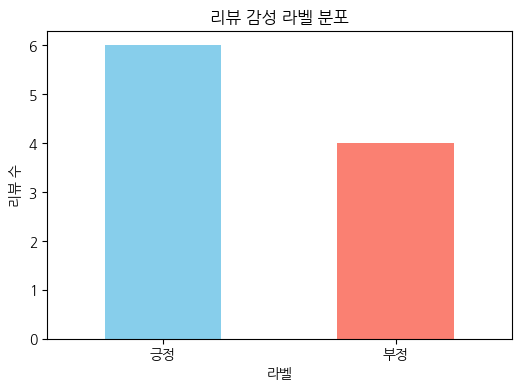

In [ ]:
# 라벨 분포 시각화
counts = df['label_name'].value_counts().reindex(['긍정', '부정'])

plt.figure(figsize=(6, 4))
# TODO 4. counts를 막대그래프로 시각화하세요.
# 힌트: counts.plot(kind='차트종류' , color=, rot=)
# ax = ___________________________________________________________
# ax.set_title('리뷰 감성 라벨 분포')
# ax.set_xlabel('라벨')
# ax.set_ylabel('리뷰 수')
# plt.show()
ax = counts.plot(kind='bar', color=['skyblue', 'salmon'], rot=0)
ax.set_title('리뷰 감성 라벨 분포')
ax.set_xlabel('라벨')
ax.set_ylabel('리뷰 수')
plt.show()


## 3. 텍스트 길이 탐색

텍스트 길이는 매우 짧거나 긴 문서, 빈 문자열, 복제된 안내 문구 등을 찾는 데 도움을 줍니다. 여기서는 문자 수와 공백 기준 어절 수를 모두 살펴봅니다.

### 체크포인트 2 — 데이터 구조

1. 이 데이터의 행 하나는 무엇을 의미하나요?
2. `label`과 `label_name`을 함께 두는 이유는 무엇인가요?
3. 현재 라벨 분포가 실제 감성분석 모델 학습용으로 충분히 균형 잡혔다고 볼 수 있는지, 근거와 함께 1~2문장으로 답하세요.


1. 데이터의 행 하나는 영화 리뷰 1개와 해당 리뷰의 번호, 감성 라벨, 작성 날짜를 의미한다.
2. label은 모델이 처리하기 쉬운 숫자 형태이고, label_name은 사람이 의미를 쉽게 확인할 수 있는 문자 형태이므로 함께 둔다.
3. 긍정 리뷰는 6개, 부정 리뷰는 4개로 비교적 균형 잡혀 있습니다. 하지만 전체 데이터가 10개뿐이므로 실제 감성분석 모델을 학습하기에는 데이터가  부족하다.

In [ ]:
# TODO 5. 문자 수(char_len)와 공백 기준 어절 수(word_len) 열을 생성하세요.
# 힌트: df['text'].str.len()
# df['char_len'] = _____________________________________________
# df['word_len'] = _____________________________________________
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()

display(df[['review_id', 'label_name', 'char_len', 'word_len', 'text']])

# 아래 표를 보고 긍정/부정 리뷰의 길이를 비교해 보세요.
display(df.groupby('label_name')[['char_len', 'word_len']].agg(['count', 'mean', 'min', 'max']).round(2))


,review_id,label_name,char_len,word_len,text
0,1,긍정,28,5,정말 재미있어요! 배우들의 연기가 인상적이었습니다.
1,2,긍정,19,4,스토리는 평범하지만 음악이 좋네요.
2,3,부정,21,4,기대보다 지루했고 결말이 아쉬웠습니다.
3,4,긍정,26,6,영상미는 훌륭합니다. 다만 전개가 조금 느려요.
4,5,부정,20,5,다시는 보고 싶지 않은 영화예요...
5,6,긍정,25,7,가족과 함께 보기 좋은 따뜻한 작품입니다 :)
6,7,부정,24,6,배우는 좋았지만 대사가 잘 들리지 않았어요.
7,8,긍정,22,6,추천합니다! 다음 편도 꼭 보고 싶어요.
8,9,부정,24,5,별로예요. 러닝타임이 너무 길게 느껴집니다.
9,10,긍정,21,5,생각할 거리를 주는 좋은 영화였습니다.


char_len                word_len             
              count   mean min max    count mean min max
label_name                                              
긍정                6  23.50  19  28        6  5.5   4   7
부정                4  22.25  20  24        4  5.0   4   6

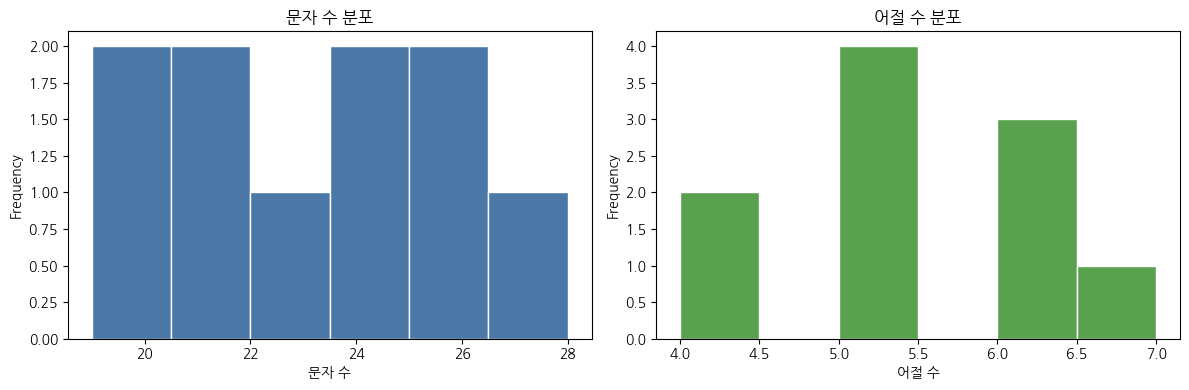

In [ ]:
# 길이 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TODO 6. char_len 열의 히스토그램을 왼쪽 그래프에 그리세요.
# 힌트: color='#4C78A8', edgecolor='white'
# ____________________________________________________________________________
df['char_len'].plot(kind='hist', bins=6, ax=axes[0], color='#4C78A8', edgecolor='white')
axes[0].set_title('문자 수 분포')
axes[0].set_xlabel('문자 수')

# 아래 코드는 실행해 어절 수 분포와 비교하세요.
df['word_len'].plot(kind='hist', bins=6, ax=axes[1], color='#59A14F', edgecolor='white')
axes[1].set_title('어절 수 분포')
axes[1].set_xlabel('어절 수')

plt.tight_layout()
plt.show()


## 4. 간단한 토큰 빈도와 어휘 다양성

빈도 분석은 코퍼스의 주제와 노이즈를 빠르게 파악하는 출발점입니다. 다만 조사·어미·불용어가 상위에 나타날 수 있으므로, 결과를 그대로 의미 있는 키워드라고 단정하면 안 됩니다.

### 체크포인트 3 — 길이 탐색

가장 짧은 리뷰와 가장 긴 리뷰를 찾아보세요. 단순히 길다는 사실만으로 오류라고 판단할 수 없는 이유와, 실제 데이터에서 추가 확인할 항목을 한 가지씩 작성하세요.


리뷰에 자신의 감상을 길게 남겼을수도 있기 때문에 단순히 길다는 사실만으로 오류라고 판단할 수 없다. 리뷰에 광고 문구가 있는지 확인한다.

In [ ]:
def simple_tokenize(text):
    """한글/영문/숫자 덩어리를 추출하는 매우 단순한 교육용 토크나이저"""
    return re.findall(r'[가-힣A-Za-z0-9]+', text.lower())

# TODO 7. 모든 리뷰에서 토큰을 모아 all_tokens 리스트를 만드세요.
# 힌트: [token for text in df['text'] for token in simple_tokenize(text)]
# all_tokens = ______________________________________________________________
all_tokens = [token for text in df['text'] for token in simple_tokenize(text)]

freq = Counter(all_tokens)
print('전체 토큰 수:', len(all_tokens))
print('고유 토큰 수:', len(freq))
print('어휘 다양성(type-token ratio):', round(len(freq) / len(all_tokens), 3))
display(pd.DataFrame(freq.most_common(15), columns=['token', 'count']))


전체 토큰 수: 52
고유 토큰 수: 50
어휘 다양성(type-token ratio): 0.962


,token,count
0,보고,2
1,좋은,2
2,정말,1
3,재미있어요,1
4,배우들의,1
5,연기가,1
6,인상적이었습니다,1
7,스토리는,1
8,평범하지만,1
9,음악이,1


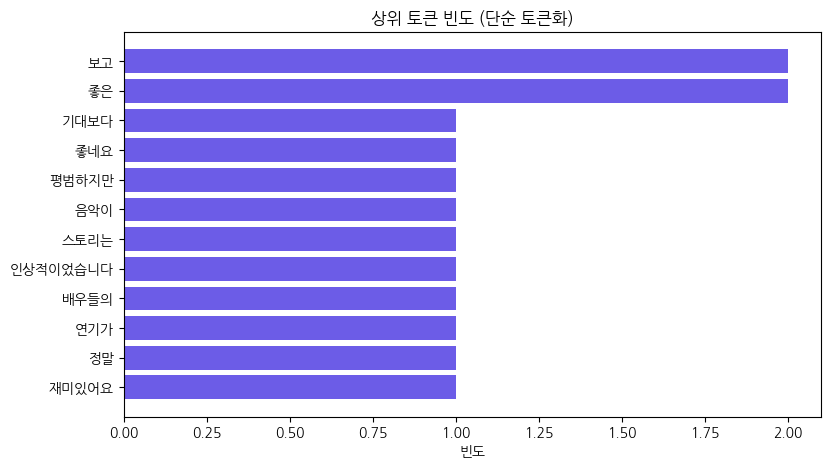

In [ ]:
# 상위 토큰 시각화
# TODO 8. freq의 상위 12개 토큰으로 token, count 열을 가진 데이터프레임을 만드세요.
# 힌트: pd.DataFrame(freq.most_common(12), columns=['token', 'count'])
# freq_df = ______________________________________________________
freq_df = pd.DataFrame(freq.most_common(12), columns=['token', 'count'])
freq_df = freq_df.sort_values('count')

plt.figure(figsize=(9, 5))
plt.barh(freq_df['token'], freq_df['count'], color='#6C5CE7')
plt.title('상위 토큰 빈도 (단순 토큰화)')
plt.xlabel('빈도')
plt.show()


### 체크포인트 2
상위 빈도 토큰 중 **감성 판단에 직접 도움이 되지 않을 수 있는 토큰**을 찾아 보세요. 이를 처리할 때 생길 수 있는 장점과 단점을 각각 한 가지씩 적어 보세요.

상위 빈도 토큰 중 '영화' 같은 토큰은 주제를 나타낼 뿐 감성 판단에는 직접적인 도움이 되지 않을 수 있다. 이런 토큰을 제거하면 중요한 감성 표현에 집중할 수 있지만, 문맥에 따라 필요한 정보까지 제거하여 분석 정확도가 낮아질 수 있다.

### 체크포인트 4 — 빈도와 어휘 다양성

상위 빈도 토큰 중 감성 판단에 직접 도움이 되지 않을 수 있는 토큰을 하나 이상 고르세요. 이를 처리할 때의 장점과 단점을 각각 한 가지씩 적으세요.


상위 빈도 토큰 중 '영화' 같은 토큰은 주제를 나타낼 뿐 감성 판단에는 직접적인 도움이 되지 않을 수 있다. 이런 토큰을 제거하면 중요한 감성 표현에 집중할 수 있지만, 문맥에 따라 필요한 정보까지 제거하여 분석 정확도가 낮아질 수 있다.

## 5. 한글 텍스트와 인코딩 확인

컴퓨터는 문자를 코드로 저장합니다. UTF-8은 가장 널리 쓰이는 문자 인코딩 중 하나이며, 한글을 포함한 다양한 문자를 표현할 수 있습니다. 파일을 잘못된 인코딩으로 읽으면 `�`처럼 깨진 문자가 나타날 수 있습니다.

또한 겉보기에는 같은 글자라도 유니코드 정규화 방식에 따라 내부 코드가 다를 수 있습니다. 데이터 병합·중복 제거 전에 확인할 가치가 있습니다.

In [ ]:
import unicodedata
text = '한글 NLP'
print('원문:', text)
print('UTF-8 바이트:', text.encode('utf-8'))

# TODO 9. UTF-8 바이트를 다시 문자열로 복원하세요.
# restored = _________________________________________________
# print('UTF-8로 복원:', restored)

restored = text.encode('utf-8').decode('utf-8')
print('UTF-8로 복원:', restored)

# 유니코드 정규화 예시
composed = '가'
decomposed = unicodedata.normalize('NFD', composed)
print('겉보기 문자열:', composed, decomposed)
print('문자열 동일 여부:', composed == decomposed)

# TODO 10. 두 문자열을 NFC로 정규화한 뒤 동일한지 확인하세요.
# print('NFC 정규화 후 동일 여부:', ____________________________________________)
print(
    'NFC 정규화 후 동일 여부:',
    unicodedata.normalize('NFC', composed) == unicodedata.normalize('NFC', decomposed)
)


원문: 한글 NLP
UTF-8 바이트: b'\xed\x95\x9c\xea\xb8\x80 NLP'
UTF-8로 복원: 한글 NLP
겉보기 문자열: 가 가
문자열 동일 여부: False
NFC 정규화 후 동일 여부: True


In [ ]:
# 간단한 품질 점검 함수: 빈 텍스트, 깨진 문자, URL/이메일/전화번호처럼 보이는 패턴을 표시
# ※ 실제 개인정보 탐지는 더 엄격한 정책과 검토가 필요합니다.
def quality_flags(text):
    flags = []
    if not isinstance(text, str) or not text.strip():
        flags.append('빈 텍스트')
    if '�' in text:
        flags.append('인코딩 깨짐 의심')
    if re.search(r'https?://\S+|www\.\S+', text):
        flags.append('URL 포함')
    if re.search(r'[\w.+-]+@[\w-]+\.[\w.-]+', text):
        flags.append('이메일 포함 가능성')
    # TODO 11. 전화번호로 보이는 패턴을 탐지하는 정규표현식을 완성하세요.
    # 힌트: r'\d{2,3}[- ]?\d{3,4}[- ]?\d{4}'
    # if re.search(_____________________________________, text):
    #     flags.append('전화번호 포함 가능성')
    if re.search(r'\d{2,3}[- ]?\d{3,4}[- ]?\d{4}', text):
        flags.append('전화번호 포함 가능성')


    return ', '.join(flags) if flags else '이상 없음'

df['quality_check'] = df['text'].apply(quality_flags)
display(df[['review_id', 'text', 'quality_check']])


,review_id,text,quality_check
0,1,정말 재미있어요! 배우들의 연기가 인상적이었습니다.,이상 없음
1,2,스토리는 평범하지만 음악이 좋네요.,이상 없음
2,3,기대보다 지루했고 결말이 아쉬웠습니다.,이상 없음
3,4,영상미는 훌륭합니다. 다만 전개가 조금 느려요.,이상 없음
4,5,다시는 보고 싶지 않은 영화예요...,이상 없음
5,6,가족과 함께 보기 좋은 따뜻한 작품입니다 :),이상 없음
6,7,배우는 좋았지만 대사가 잘 들리지 않았어요.,이상 없음
7,8,추천합니다! 다음 편도 꼭 보고 싶어요.,이상 없음
8,9,별로예요. 러닝타임이 너무 길게 느껴집니다.,이상 없음
9,10,생각할 거리를 주는 좋은 영화였습니다.,이상 없음


## 6. 미니 실습: 감성별 자주 등장하는 토큰 비교

아래 분석은 **매우 단순한 탐색**입니다. 리뷰 수가 적고, 형태소 분석·불용어 처리·부정 표현 처리도 하지 않았습니다. 따라서 인과관계나 일반적 성능을 주장할 수 없습니다.

### 체크포인트 5 — 인코딩·품질·윤리

UTF-8 인코딩 또는 NFC 정규화를 통일하지 않으면 중복 제거·검색·모델 입력에서 어떤 문제가 생길 수 있나요? 또한 URL·이메일·전화번호를 탐지하는 이유를 개인정보 관점에서 설명하세요.


UTF-8 인코딩이나 NFC 정규화를 통일하지 않으면 화면상 같은 글자도 서로 다른 문자열로 처리되어 중복 제거와 검색이 제대로 되지 않을 수 있다. URL·이메일·전화번호는 개인을 식별하거나 연락하는 데 사용될 수 있으므로, 개인정보 유출을 막기 위해 미리 탐지하여 삭제하거나 마스킹해야 한다.

In [ ]:
def top_tokens_by_label(data, label, n=10):
    texts = data.loc[data['label'] == label, 'text']
    tokens = [tok for text in texts for tok in simple_tokenize(text)]
    return pd.DataFrame(Counter(tokens).most_common(n), columns=['token', 'count'])

# TODO 12. 긍정(1)과 부정(0) 리뷰의 상위 토큰을 각각 구하세요.
# positive_top = top_tokens_by_label(___________________________)
# negative_top = top_tokens_by_label(___________________________)
positive_top = top_tokens_by_label(df, 1, n=10)
negative_top = top_tokens_by_label(df, 0, n=10)

print('긍정 리뷰 상위 토큰')
display(positive_top)
print('부정 리뷰 상위 토큰')
display(negative_top)


긍정 리뷰 상위 토큰


,token,count
0,좋은,2
1,정말,1
2,재미있어요,1
3,배우들의,1
4,연기가,1
5,인상적이었습니다,1
6,스토리는,1
7,평범하지만,1
8,음악이,1
9,좋네요,1


부정 리뷰 상위 토큰


,token,count
0,기대보다,1
1,지루했고,1
2,결말이,1
3,아쉬웠습니다,1
4,다시는,1
5,보고,1
6,싶지,1
7,않은,1
8,영화예요,1
9,배우는,1


## 7. 실습 정리: 분석 전 점검표

모델을 학습하기 전 아래 질문에 답할 수 있어야 합니다.

- [ ] 데이터의 **출처·수집 목적·이용 허가**를 확인했는가?
- [ ] 개인식별정보(이름, 연락처, 이메일 등)와 민감정보를 점검했는가?
- [ ] 문서/문장/토큰 중 분석 단위를 명확히 정했는가?
- [ ] 결측치·중복·깨진 문자·비정상적으로 긴/짧은 텍스트를 확인했는가?
- [ ] 라벨 분포가 치우쳐 있지 않은가?
- [ ] 결과가 데이터 규모와 전처리 한계에 비추어 과장되지 않았는가?

다음 주차에는 이 데이터를 바탕으로 정규화, 정제, 토큰화와 한글 형태소 분석을 다룹니다.


### 체크포인트 6 — 결과 해석의 한계

긍정·부정 상위 토큰을 비교해 관찰한 점을 2문장 이내로 적으세요. 단, 이 결과만으로 특정 단어가 감성을 결정한다고 단정할 수 없는 이유도 포함하세요.


긍정 리뷰에는 재미있어요, 좋네요 같은 표현이, 부정 리뷰에는 지루했고, 아쉬웠습니다 같은 표현이 주로 나타났다. 하지만 데이터가 적고 문맥을 고려하지 않았기 때문에, 특정 단어 하나가 감성을 결정한다고 단정할 수 없다.

## 제출 과제: 분석 결과와 해석 기록

아래 항목을 모두 완료한 뒤, 실행 결과가 포함된 노트북을 제출합니다.

- [ ] TODO 1~12를 작성·실행했다.
- [ ] 공백 토큰화와 정규표현식 토큰화의 차이를 설명했다.
- [ ] 데이터 구조, 결측치, 중복 및 라벨 분포를 점검했다.
- [ ] 문자 수와 어절 수 분포에서 관찰한 특징을 기록했다.
- [ ] 상위 빈도 토큰 중 불용어 후보와 그 근거를 설명했다.
- [ ] UTF-8·NFC 정규화가 필요한 이유를 설명했다.
- [ ] 데이터 품질·개인정보·저작권 관점에서 주의할 점을 기록했다.

### 도전 과제 (선택 가산 또는 심화)
1. 예시 데이터에 리뷰 5개 이상을 직접 추가하고, 라벨 분포와 상위 토큰이 어떻게 달라졌는지 기록하세요.
2. `quality_flags`에 **반복 문자**(예: `ㅋㅋㅋㅋ`, `!!!!`)를 탐지하는 규칙을 추가하세요. 이 규칙이 오탐할 수 있는 사례도 한 가지 설명하세요.
3. 공백 토큰화의 한계를 한글 예시와 함께 설명하고, 다음 주차에 사용할 형태소 분석기가 이를 어떻게 보완할지 예상해 보세요.
4. 외부 데이터셋을 사용한다면 출처, 라이선스, 개인정보 처리 방침을 README에 명시하세요.


In [ ]:
# @title 0.예시데이터
import pandas as pd
import re
from collections import Counter

reviews = [
    (1, '정말 재미있어요! 배우들의 연기가 인상적이었습니다.', 1, '2026-08-25'),
    (2, '스토리는 평범하지만 음악이 좋네요.', 1, '2026-08-25'),
    (3, '기대보다 지루했고 결말이 아쉬웠습니다.', 0, '2026-08-26'),
    (4, '영상미는 훌륭합니다. 다만 전개가 조금 느려요.', 1, '2026-08-26'),
    (5, '다시는 보고 싶지 않은 영화예요...', 0, '2026-08-27'),
    (6, '가족과 함께 보기 좋은 따뜻한 작품입니다 :)', 1, '2026-08-27'),
    (7, '배우는 좋았지만 대사가 잘 들리지 않았어요.', 0, '2026-08-28'),
    (8, '추천합니다! 다음 편도 꼭 보고 싶어요.', 1, '2026-08-28'),
    (9, '별로예요. 러닝타임이 너무 길게 느껴집니다.', 0, '2026-08-29'),
    (10, '생각할 거리를 주는 좋은 영화였습니다.', 1, '2026-08-29'),
]

df = pd.DataFrame(reviews, columns=["id", "text", "label", "date"])
df["date"] = pd.to_datetime(df["date"])

print("원본 데이터 건수:", len(df))
df


In [ ]:
# @title 1. 리뷰 5개 이상 추가 후 라벨 분포·상위 토큰 비교
new_reviews = [
    (11, '배경 음악과 촬영 기법이 정말 인상 깊었습니다.', 1, '2026-08-30'),
    (12, '개연성이 부족하고 캐릭터가 매력이 없어요.', 0, '2026-08-30'),
    (13, '연출은 좋았지만 결말 처리가 아쉬웠습니다.', 0, '2026-08-31'),
    (14, '몰입감이 대단했고 배우들의 연기력이 훌륭했어요!', 1, '2026-08-31'),
    (15, '기대했던 것보다 훨씬 실망스러운 영화였습니다.', 0, '2026-09-01'),
    (16, '아이들과 함께 보기에 딱 좋은 영화였어요 :)', 1, '2026-09-01'),
]




In [ ]:
# @title 2. quality_flags에 반복 문자('ㅋㅋㅋㅋ', '!!!!', '...' 등) 탐지 규칙 추가


In [ ]:
# @title 3. 공백 토큰화의 한계와 형태소 분석기의 보완 예상


In [ ]:
# @title 4. 외부 데이터셋 사용 시 README 작성

readme_content = """# 데이터셋 정보 (Data Card)

## 1. 출처 (Source)
- 데이터셋 이름: 영화 리뷰 감성 분석 실습 데이터
- 구성: 자체 작성 예시 리뷰(reviews 리스트, 16건) + 외부 데이터셋 병합 시 하단에 출처 추가 기입
- 원본 제공처: (외부 데이터셋 사용 시 예: 네이버 영화 리뷰 공개 코퍼스 / AI Hub)
- 원본 URL: (외부 데이터셋 사용 시 링크 기입)
- 수집 방식: 자체 작성 / (외부 데이터셋 사용 시: Open API 활용 / 공개 데이터셋 다운로드 등)
- 수집(작성) 일자: 2026-08-25 ~ 2026-09-01

## 2. 라이선스 (License)
- 자체 작성 데이터: 교육 목적 실습용, 재배포 시 출처 표기 요망
- 외부 데이터셋 병합 시: 라이선스 종류(예: CC BY 4.0), 상업적 이용 가능 여부, 재배포 조건을 원본 제공처 약관에 따라 명시

## 3. 개인정보 처리 방침 (Privacy Policy)
- PII 포함 여부: 없음 (실명, 연락처, 주소 등 개인식별정보 미포함 확인 완료)
- 비식별화 처리 여부: 해당 없음 (원천적으로 PII 미포함)
- 향후 외부 크롤링 데이터 병합 시: 정규표현식 기반 전화번호·이메일 탐지 및 마스킹 처리 예정

## 4. 데이터 구성
- 총 건수: 16건 (label 1=긍정 9건, label 0=부정 7건)
- 컬럼 설명: id(리뷰 고유번호), text(리뷰 본문), label(감성 라벨, 1=긍정/0=부정), date(작성일자)
- quality_flags: 결측(empty_text), 반복문자(repeated_char), 특수문자 과다(too_many_special_chars) 탐지 결과

## 5. 알려진 한계 (Known Limitations)
- 표본 수가 16건으로 매우 적어 통계적 일반화에 한계가 있음
- 공백 토큰화 기준 분석 시 조사/어미로 인한 토큰 분산 문제 존재 (형태소 분석 적용 권장)
- 반복 문자 탐지 규칙은 감정 표현(ㅠㅠ, ㅋㅋ 등)을 노이즈로 오탐할 가능성 있음
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md 파일이 생성되었습니다.")
print(readme_content)